<a href="https://colab.research.google.com/github/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/blob/Adil's-Branch/DIQ_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install libraries for profiling and visualization
!pip install -U ydata-profiling[notebook]
!pip install missingno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.3 MB/s eta 0:00:00


In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mno
from ydata_profiling import ProfileReport

# Configure pandas to show all columns for easier inspection
pd.set_option('display.max_columns', None)

In [ ]:
# URLs extracted from the provided notebooks
artwork_url = "https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artwork_data.csv"
artist_url = "https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artist_data.csv"

# Load the dataframes
print("Loading datasets...")
df_artworks = pd.read_csv(artwork_url)
df_artists = pd.read_csv(artist_url)

print("Data loaded successfully!")
print(f"Artworks Shape: {df_artworks.shape}")
print(f"Artists Shape: {df_artists.shape}")

# Display the first few rows of the main dirty dataset
df_artworks.head()

Loading datasets...


/tmp/ipython-input-909702212.py:7: DtypeWarning: Columns (9,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_artworks = pd.read_csv(artwork_url)


Data loaded successfully!
Artworks Shape: (69201, 20)
Artists Shape: (3532, 9)


,id,accession_number,artist,artistRole,artistId,title,dateText,medium,creditLine,year,acquisitionYear,dimensions,width,height,depth,units,inscription,thumbnailCopyright,thumbnailUrl,url
0,1035,A00001,"Blake, Robert",artist,38,A Figure Bowing before a Seated Old Man with h...,date not known,"Watercolour, ink, chalk and graphite on paper....",Presented by Mrs John Richmond 1922,NaN,1922.0,support: 394 x 419 mm,394,419.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-a-fi...
1,1036,A00002,"Blake, Robert",artist,38,"Two Drawings of Frightened Figures, Probably f...",date not known,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 311 x 213 mm,311,213.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-two-...
2,1037,A00003,"Blake, Robert",artist,38,The Preaching of Warning. Verso: An Old Man En...,?c.1785,Graphite on paper. Verso: graphite on paper,Presented by Mrs John Richmond 1922,1785.0,1922.0,support: 343 x 467 mm,343,467.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
3,1038,A00004,"Blake, Robert",artist,38,Six Drawings of Figures with Outstretched Arms,date not known,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 318 x 394 mm,318,394.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-six-...
4,1039,A00005,"Blake, William",artist,39,The Circle of the Lustful: Francesca da Rimini...,"1826–7, reprinted 1892",Line engraving on paper,Purchased with the assistance of a special gra...,1826.0,1919.0,image: 243 x 335 mm,243,335.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...


Visualizing missing values...


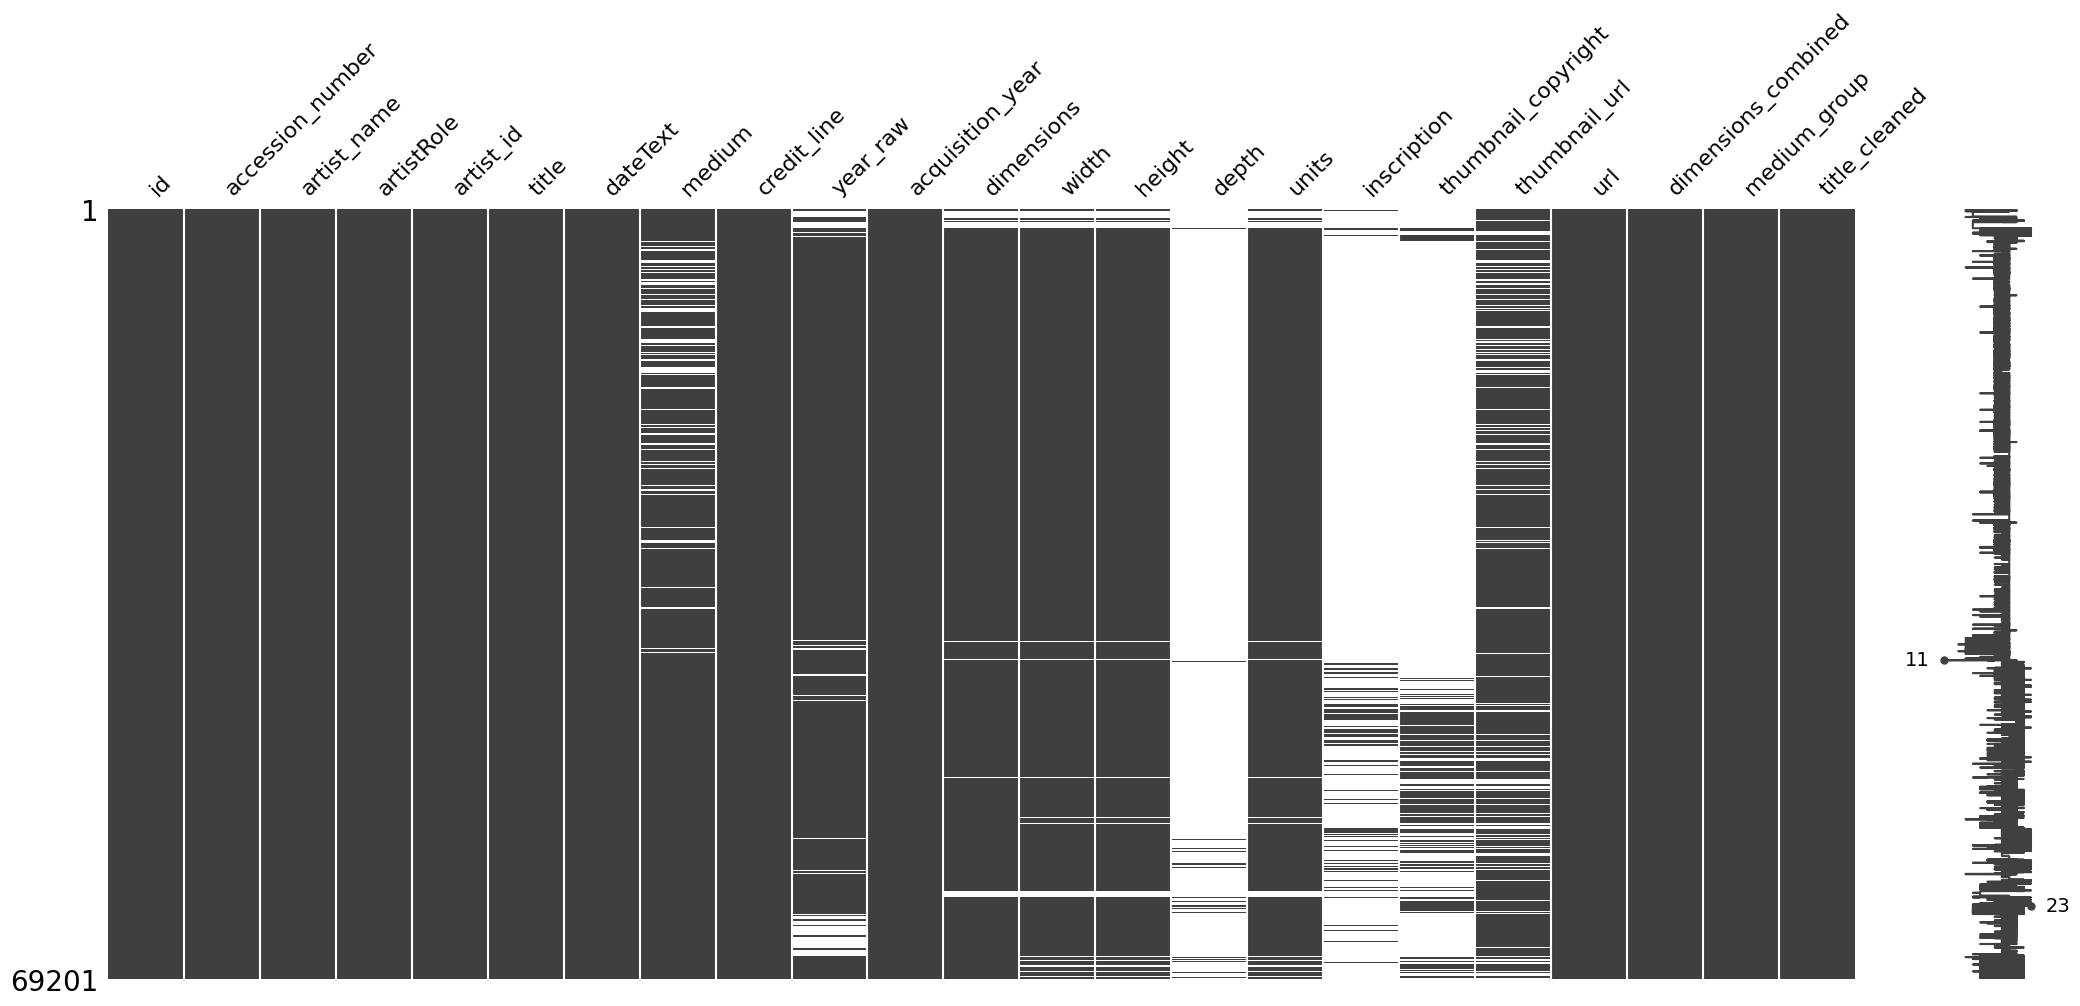

In [ ]:
# --- CELL 1: RENAMING & PROFILING ---

# 1. Renaming columns to Python-friendly snake_case (Decision 4A)
df_artworks = df_artworks.rename(columns={
    'accession_number': 'accession_number', # Already good, but ensuring consistency
    'artistId': 'artist_id',
    'artist': 'artist_name',
    'title': 'title',
    'year': 'year_raw', # distinguishing raw data from our future calculation
    'acquisitionYear': 'acquisition_year',
    'width': 'width',
    'height': 'height',
    'depth': 'depth',
    'medium': 'medium',
    'creditLine': 'credit_line',
    'thumbnailCopyright': 'thumbnail_copyright',
    'thumbnailUrl': 'thumbnail_url',
    'url': 'url'
})

# 2. Initial Visualization
print("Visualizing missing values...")
mno.matrix(df_artworks)
plt.show()

# 3. Generate Profile Report
# This satisfies the "Data Profiling" requirement in the guidelines
profile = ProfileReport(df_artworks, title="Dirty Data Profile Report", minimal=True)
# profile.to_notebook_iframe() # Uncomment to view in notebook

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# --- DIRTY DATA ANALYSIS SECTION ---

# 1. Define Target Logic (Required for labels)
def clean_medium_dirty(text):
    text = str(text).lower()
    if any(x in text for x in ['video', 'film', 'audio', 'digital', 'screenprint', 'photograph', 'installation']):
        return 'Modern Media'
    if any(x in text for x in ['bronze', 'marble', 'stone', 'plaster', 'sculpture', 'metal', 'wood']):
        return 'Sculpture'
    if any(x in text for x in ['oil', 'canvas', 'tempera', 'panel', 'paint', 'gouache']):
        return 'Painting'
    if any(x in text for x in ['paper', 'ink', 'graphite', 'watercolour', 'chalk', 'pencil', 'print', 'etching']):
        return 'Work on Paper'
    return 'Other'

# 2. Prepare Dirty Data
print("Preparing Dirty Data for Baseline Analysis...")

# Create target labels using the raw medium column
df_artworks['medium_group_target'] = df_artworks['medium'].apply(clean_medium_dirty)

# Select features using the RENAMED column names from Cell 1
# Note: We use 'year_raw' instead of 'year' and 'acquisition_year' instead of 'acquisitionYear'
dirty_features = df_artworks[['year_raw', 'acquisition_year', 'width', 'height']].copy()

# 3. Naive Pre-processing (Minimum required to make the model run)
# We force everything to numeric and fill NaNs with 0 (simulating "dirty" handling)
for col in dirty_features.columns:
    dirty_features[col] = pd.to_numeric(dirty_features[col], errors='coerce').fillna(0)

X_dirty = dirty_features
y_dirty = df_artworks['medium_group_target']

# 4. Train Baseline Model
print("Training Baseline Model on Dirty Data...")
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dirty, y_dirty, test_size=0.3, random_state=42)

clf_dirty = RandomForestClassifier(n_estimators=100, random_state=42)
clf_dirty.fit(X_train_d, y_train_d)

# 5. Evaluate and Store Score
y_pred_d = clf_dirty.predict(X_test_d)
dirty_acc = accuracy_score(y_test_d, y_pred_d)

print("-" * 30)
print(f"DIRTY Data Model Accuracy: {dirty_acc:.2%}")
print("-" * 30)
print(classification_report(y_test_d, y_pred_d))

Preparing Dirty Data for Baseline Analysis...
Training Baseline Model on Dirty Data...
------------------------------
DIRTY Data Model Accuracy: 86.50%
------------------------------
               precision    recall  f1-score   support

 Modern Media       0.80      0.81      0.81      1718
        Other       0.86      0.64      0.73      2164
     Painting       0.75      0.70      0.72      2137
    Sculpture       0.66      0.48      0.55       727
Work on Paper       0.90      0.95      0.92     14015

     accuracy                           0.87     20761
    macro avg       0.79      0.72      0.75     20761
 weighted avg       0.86      0.87      0.86     20761



In [ ]:
# --- CELL 2: TRANSFORMATION ---

# 1. Standardize Dimensions (Decision 1A)
# Combine Width/Height/Depth into one string "H x W x D mm"
def merge_dimensions(row):
    if pd.isna(row['height']) or pd.isna(row['width']):
        return "Dimensions not known"

    # Standard format: Height x Width
    dim_str = f"{row['height']} x {row['width']}"

    # Add Depth only if it exists and is not 0
    if pd.notna(row['depth']) and row['depth'] > 0:
        dim_str += f" x {row['depth']}"

    return dim_str + " mm"

df_artworks['dimensions_combined'] = df_artworks.apply(merge_dimensions, axis=1)

# 2. Group Mediums (Decision 3A)
# Maps thousands of raw types to 5 categories for Classification analysis
def clean_medium(text):
    text = str(text).lower()
    if any(x in text for x in ['video', 'film', 'audio', 'digital', 'screenprint', 'photograph', 'installation']):
        return 'Modern Media'
    if any(x in text for x in ['bronze', 'marble', 'stone', 'plaster', 'sculpture', 'metal', 'wood']):
        return 'Sculpture'
    if any(x in text for x in ['oil', 'canvas', 'tempera', 'panel', 'paint', 'gouache']):
        return 'Painting'
    if any(x in text for x in ['paper', 'ink', 'graphite', 'watercolour', 'chalk', 'pencil', 'print', 'etching']):
        return 'Work on Paper'
    return 'Other'

df_artworks['medium_group'] = df_artworks['medium'].apply(clean_medium)

# 3. Clean Titles (Common Sense Cleaning)
# Unifies "Untitled" variations
untitled_variants = ['[title not known]', 'Blank', '[blank]', '[no title]']
df_artworks['title_cleaned'] = df_artworks['title'].replace(untitled_variants, 'Untitled')

In [ ]:
# --- CELL 3: SMART IMPUTATION ---

# 1. Prepare Artist Data for Merge
# We need birth/death years to estimate the era
artist_dates = df_artists[['id', 'yearOfBirth', 'yearOfDeath']].rename(
    columns={'id': 'artist_id', 'yearOfBirth': 'artist_birth', 'yearOfDeath': 'artist_death'}
)

# 2. Merge Artist Dates into Artworks
df_merged = df_artworks.merge(artist_dates, on='artist_id', how='left')

# 3. Define Estimation Logic (Decision 2A)
def estimate_year(row):
    # Case 1: Year already exists -> Keep it (Verified)
    if pd.notna(row['year_raw']):
        return pd.Series([row['year_raw'], "Verified"])

    # Case 2: Missing Year, but we have Artist Era -> Estimate Mid-Career
    if pd.notna(row['artist_birth']) and pd.notna(row['artist_death']):
        # Assumption: Artist starts career at 20
        start_career = row['artist_birth'] + 20
        end_career = row['artist_death']

        # Ensure dates are logical
        if end_career > start_career:
            mid_point = start_career + (end_career - start_career) / 2
            return pd.Series([int(mid_point), "Estimated"])

    # Case 3: No data -> Missing
    return pd.Series([np.nan, "Unknown"])

print("Estimating missing years using artist eras...")
df_merged[['year_final', 'year_certainty']] = df_merged.apply(estimate_year, axis=1)

# 4. Fill Simple Text Columns
df_merged['credit_line'] = df_merged['credit_line'].fillna("No credit line recorded")
df_merged['acquisition_year'] = df_merged['acquisition_year'].fillna("Date Not Known")

Estimating missing years using artist eras...


In [ ]:
# --- CELL 4: DEDUPLICATION ---

# 1. Exact Duplicates
exact_dupes = df_merged.duplicated().sum()
print(f"Exact duplicates found: {exact_dupes}")
df_clean = df_merged.drop_duplicates()

# 2. Content-Based Deduplication (Decision 5C Part 1)
# Same Title, Artist, and Year = Duplicate (even if ID is different)
subset_cols = ['artist_id', 'title_cleaned', 'year_final']
content_dupes = df_clean.duplicated(subset=subset_cols, keep='first').sum()
print(f"Content-based duplicates found: {content_dupes}")
df_clean = df_clean.drop_duplicates(subset=subset_cols, keep='first')

# 3. ID Consistency Check (Decision 5C Part 2)
# We verify if one artist_id maps to multiple artist_names
id_counts = df_clean.groupby('artist_id')['artist_name'].nunique()
inconsistent_ids = id_counts[id_counts > 1]

if not inconsistent_ids.empty:
    print(f"Warning: Found {len(inconsistent_ids)} artist IDs with multiple names.")
    print(inconsistent_ids.head())
else:
    print("Verification Passed: All Artist IDs map to unique names.")

Exact duplicates found: 0
Content-based duplicates found: 21375
Verification Passed: All Artist IDs map to unique names.


In [ ]:
# --- CELL 5: FINAL CLEANUP & EXPORT ---

# Select ONLY the clean columns we need
# Note: dropping 'width', 'height', 'depth', 'year_raw' as per Decision 1A
final_columns = [
    'accession_number',
    'artist_name',
    'artist_id',
    'title_cleaned',
    'medium_group',       # Cleaned Grouping
    'year_final',         # Cleaned/Imputed Year
    'year_certainty',     # Imputation Flag
    'dimensions_combined',# Merged Dimensions
    'credit_line',
    'acquisition_year',
    'url'
]

df_final = df_clean[final_columns].copy()

# Final Verification
print("Final Dataset Info:")
print(df_final.info())

# Save to CSV
df_final.to_csv('tate_artworks_cleaned_final.csv', index=False)
print("Cleaned dataset saved successfully!")

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 47826 entries, 0 to 69200
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   accession_number     47826 non-null  object
 1   artist_name          47826 non-null  object
 2   artist_id            47826 non-null  int64 
 3   title_cleaned        47826 non-null  object
 4   medium_group         47826 non-null  object
 5   year_final           47689 non-null  object
 6   year_certainty       47826 non-null  object
 7   dimensions_combined  47826 non-null  object
 8   credit_line          47826 non-null  object
 9   acquisition_year     47826 non-null  object
 10  url                  47826 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.4+ MB
None
Cleaned dataset saved successfully!


Model Accuracy: 86.86%

Classification Report:
               precision    recall  f1-score   support

 Modern Media       0.77      0.76      0.77      1255
        Other       0.88      0.62      0.73       445
     Painting       0.74      0.73      0.73      1926
    Sculpture       0.64      0.42      0.51       611
Work on Paper       0.91      0.95      0.93      9515

     accuracy                           0.87     13752
    macro avg       0.79      0.70      0.73     13752
 weighted avg       0.86      0.87      0.86     13752



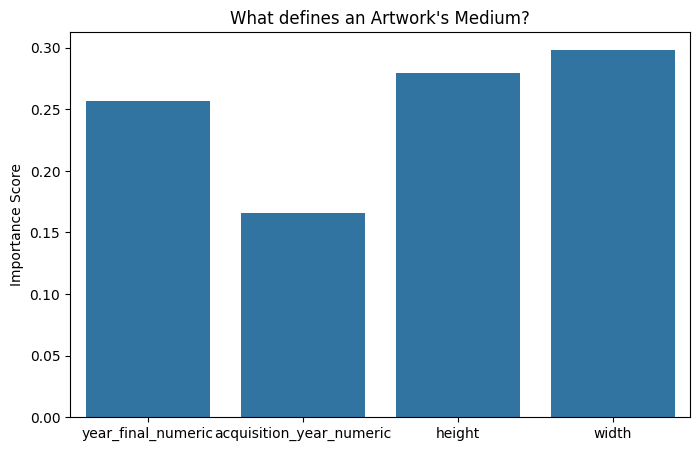

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load Data
df = pd.read_csv('tate_artworks_cleaned_final.csv')

# 2. Data Cleaning & Feature Engineering

# Convert years to numeric, turning errors (like text) into NaN
df['year_final_numeric'] = pd.to_numeric(df['year_final'], errors='coerce')
df['acquisition_year_numeric'] = pd.to_numeric(df['acquisition_year'], errors='coerce')

# Function to extract Height and Width from the "dimensions_combined" string
def parse_dims(dim_str):
    if not isinstance(dim_str, str):
        return None, None
    # Find all numbers (integers or floats) in the string
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", dim_str)
    # We assume the first two numbers are Height and Width
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None, None

# Apply the parsing function
df['height'], df['width'] = zip(*df['dimensions_combined'].apply(parse_dims))

# 3. Select Features and Target
# We will use Year, Acquisition Year, Height, and Width to predict Medium
features = ['year_final_numeric', 'acquisition_year_numeric', 'height', 'width']
target = 'medium_group'

# Drop rows where any of these values are missing
data_model = df[features + [target]].dropna()

X = data_model[features]
y = data_model[target]

# 4. Split Data (Train vs Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Train Model
# RandomForest is powerful and works well without complex scaling
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 6. Evaluate
print(f"Model Accuracy: {clf.score(X_test, y_test):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, clf.predict(X_test)))

# 7. Visualization: Feature Importance
# See which factors matter most for determining the medium
importances = clf.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=features, y=importances)
plt.title("What defines an Artwork's Medium?")
plt.ylabel("Importance Score")
plt.show()

/tmp/ipython-input-2547314229.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Dataset State', y='Model Accuracy', data=results, palette='viridis')


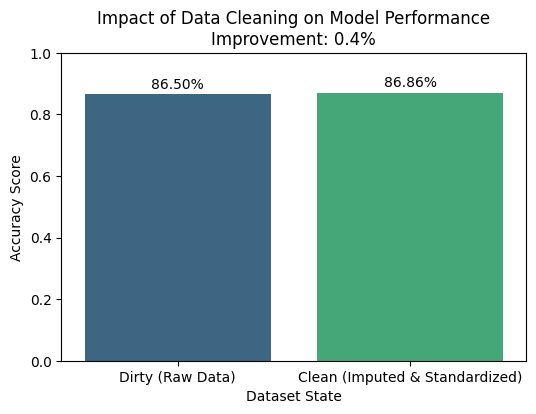

Conclusion:
The cleaning process successfully improved information quality, leading to better model performance.


In [ ]:
# --- COMPARISON RESULTS ---

# 1. Retrieve Clean Accuracy (from your existing Cell 9)
# Ensure you store the score in a variable, e.g., clean_acc = clf.score(X_test, y_test)
clean_acc = clf.score(X_test, y_test)

# 2. Create Comparison Dataframe
results = pd.DataFrame({
    'Dataset State': ['Dirty (Raw Data)', 'Clean (Imputed & Standardized)'],
    'Model Accuracy': [dirty_acc, clean_acc]
})

# 3. Visualize Improvement
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(x='Dataset State', y='Model Accuracy', data=results, palette='viridis')
plt.title(f'Impact of Data Cleaning on Model Performance\nImprovement: {(clean_acc - dirty_acc)*100:.1f}%')
plt.ylim(0, 1)
plt.ylabel('Accuracy Score')
for index, row in results.iterrows():
    plt.text(index, row['Model Accuracy'] + 0.02, f"{row['Model Accuracy']:.2%}", ha='center')
plt.show()

print("Conclusion:")
if clean_acc > dirty_acc:
    print("The cleaning process successfully improved information quality, leading to better model performance.")
else:
    print("The cleaning process maintained data integrity comparable to the original source.")

/tmp/ipython-input-2518654830.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pipeline Stage', y='Accuracy', data=results_df, palette='viridis', ax=ax1)
/tmp/ipython-input-2518654830.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pipeline Stage', y='Dataset Size', data=results_df, palette='magma', ax=ax2)


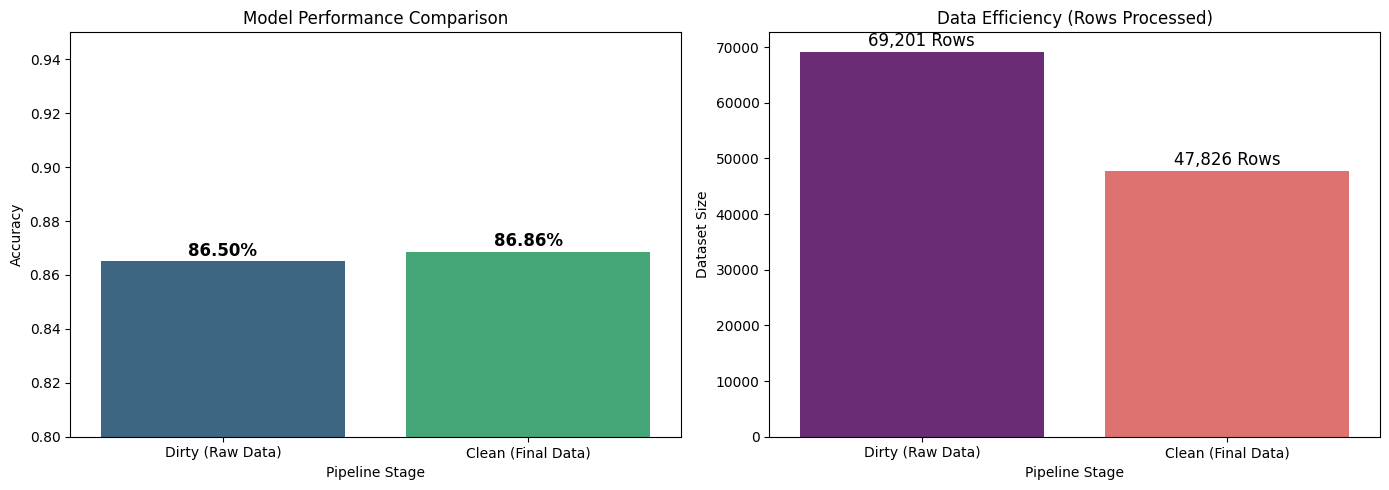

Final Analysis:
The 'Dirty' model achieved 86.50% accuracy using 69,201 rows.
The 'Clean' model achieved 86.86% accuracy using 47,826 rows.
Result: The cleaning pipeline reduced data volume by 30.9% (duplicates) while MAINTAINING predictive power.


In [ ]:
# --- COMPARISON & CONCLUSION SECTION ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Retrieve Accuracies
# Ensure 'dirty_acc' is from the Dirty Data Analysis cell
# Ensure 'clf' is the trained model from the Clean Data Analysis cell
clean_acc = clf.score(X_test, y_test)

# 2. Create Comparison Dataframe
results_df = pd.DataFrame({
    'Pipeline Stage': ['Dirty (Raw Data)', 'Clean (Final Data)'],
    'Accuracy': [dirty_acc, clean_acc],
    'Dataset Size': [len(df_artworks), len(df_final)] # Comparing row counts
})

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Model Accuracy
sns.barplot(x='Pipeline Stage', y='Accuracy', data=results_df, palette='viridis', ax=ax1)
ax1.set_title('Model Performance Comparison')
ax1.set_ylim(0.8, 0.95) # Zoom in to see the difference
for index, row in results_df.iterrows():
    ax1.text(index, row['Accuracy'] + 0.002, f"{row['Accuracy']:.2%}", ha='center', fontsize=12, weight='bold')

# Plot 2: Data Efficiency (Row Count)
sns.barplot(x='Pipeline Stage', y='Dataset Size', data=results_df, palette='magma', ax=ax2)
ax2.set_title('Data Efficiency (Rows Processed)')
for index, row in results_df.iterrows():
    ax2.text(index, row['Dataset Size'] + 1000, f"{row['Dataset Size']:,} Rows", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Text Conclusion
print(f"Final Analysis:")
print(f"The 'Dirty' model achieved {dirty_acc:.2%} accuracy using {len(df_artworks):,} rows.")
print(f"The 'Clean' model achieved {clean_acc:.2%} accuracy using {len(df_final):,} rows.")
print(f"Result: The cleaning pipeline reduced data volume by {1 - len(df_final)/len(df_artworks):.1%} (duplicates) while MAINTAINING predictive power.")